# 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Load Jupyter Notebooks

In [2]:
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

X_train = np.load(SAVE_PATH + "X_train.npy")
y_train = np.load(SAVE_PATH + "y_train.npy")
X_val   = np.load(SAVE_PATH + "X_val.npy")
y_val   = np.load(SAVE_PATH + "y_val.npy")
X_test  = np.load(SAVE_PATH + "X_test.npy")
y_test  = np.load(SAVE_PATH + "y_test.npy")

print("Loaded shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

Loaded shapes:
X_train: (11928, 64, 64, 3)
y_train: (11928,)
X_val:   (2106, 64, 64, 3)
y_val:   (2106,)
X_test:  (3000, 64, 64, 3)
y_test:  (3000,)


# 3. Convert Numpy Arrays to PyTorch Tensors

In [3]:
# PyTorch expects shape (N, C, H, W), but our arrays are (N, H, W, C)
# so we permute the axes: (0,3,1,2) moves the channels dim from last to second

def to_tensor(X, y):
    X_t = torch.tensor(X).permute(0, 3, 1, 2)  # (N,H,W,C) → (N,C,H,W)
    y_t = torch.tensor(y, dtype=torch.long)
    return X_t, y_t

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t,   y_val_t   = to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = to_tensor(X_test,  y_test)

# 4. Wrap within DataLoader

In [4]:
X_train_cnn = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_cnn   = torch.tensor(X_val,   dtype=torch.float32).permute(0, 3, 1, 2)
X_test_cnn  = torch.tensor(X_test,  dtype=torch.float32).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_cnn, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_cnn,   y_val_t),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_cnn,  y_test_t),  batch_size=64, shuffle=False)

print("Train batch shape:", next(iter(train_loader))[0].shape)

Train batch shape: torch.Size([64, 3, 64, 64])


# 5. Define Model, Loss Function, and Optimizer

In [5]:
# Architecture: 3 conv blocks → flatten → 2 FC layers → 6 class output
# Each conv block: Conv2d → BatchNorm → ReLU → MaxPool
# BatchNorm stabilizes training; MaxPool halves the spatial dimensions each time

class ImageClassifierCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Block 1: 3 input channels → 32 feature maps, output: 32×32×32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 64×64 → 32×32
        )

        # Block 2: 32 → 64 feature maps, output: 64×16×16
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 32×32 → 16×16
        )

        # Block 3: 64 → 128 feature maps, output: 128×8×8
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 16×16 → 8×8
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(256 * 8 * 8, 512),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model     = ImageClassifierCNN(num_classes=6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


# 6. Early Stopping

In [6]:
# how many epochs to wait for improvement before stopping
patience      = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_weights  = None           # store the best model weights

EPOCHS = 50

# 7. Train

In [7]:
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(X_batch)       # forward pass
        loss = criterion(outputs, y_batch)
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)

            val_loss    += loss.item() * X_batch.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    val_losses.append(val_loss / val_total)
    val_accs.append(val_correct / val_total)

# Check if validation loss improved
    if val_losses[-1] < best_val_loss:
        best_val_loss     = val_losses[-1]    # update best loss
        epochs_no_improve = 0                 # reset patience counter
        best_weights = copy.deepcopy(model.state_dict())

    else:
        epochs_no_improve = epochs_no_improve + 1


    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"Train loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}  |  "
          f"Val loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

    # Stop training if patience is finihsed
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} — val loss hasn't improved in {patience} epochs")
        break

# restore best weights
model.load_state_dict(best_weights)
print(f"Restored best weights from epoch with val loss: {best_val_loss:.4f}")

Epoch  1/50  Train loss: 1.5656  Acc: 0.5718  |  Val loss: 0.8304  Acc: 0.6800
Epoch  2/50  Train loss: 0.8071  Acc: 0.7013  |  Val loss: 0.7112  Acc: 0.7521
Epoch  3/50  Train loss: 0.6705  Acc: 0.7591  |  Val loss: 1.1460  Acc: 0.6182
Epoch  4/50  Train loss: 0.5777  Acc: 0.7933  |  Val loss: 0.5898  Acc: 0.7906
Epoch  5/50  Train loss: 0.5515  Acc: 0.8047  |  Val loss: 0.6331  Acc: 0.7707
Epoch  6/50  Train loss: 0.5068  Acc: 0.8172  |  Val loss: 0.6101  Acc: 0.8006
Epoch  7/50  Train loss: 0.4794  Acc: 0.8266  |  Val loss: 0.7566  Acc: 0.7502
Epoch  8/50  Train loss: 0.4596  Acc: 0.8345  |  Val loss: 0.7439  Acc: 0.7593
Epoch  9/50  Train loss: 0.4248  Acc: 0.8479  |  Val loss: 0.8042  Acc: 0.7360

Early stopping at epoch 9 — val loss hasn't improved in 5 epochs
Restored best weights from epoch with val loss: 0.5898


# 8. Evaluate

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")


Test Accuracy: 0.7967  (79.67%)


# 9. Plot Loss Curve

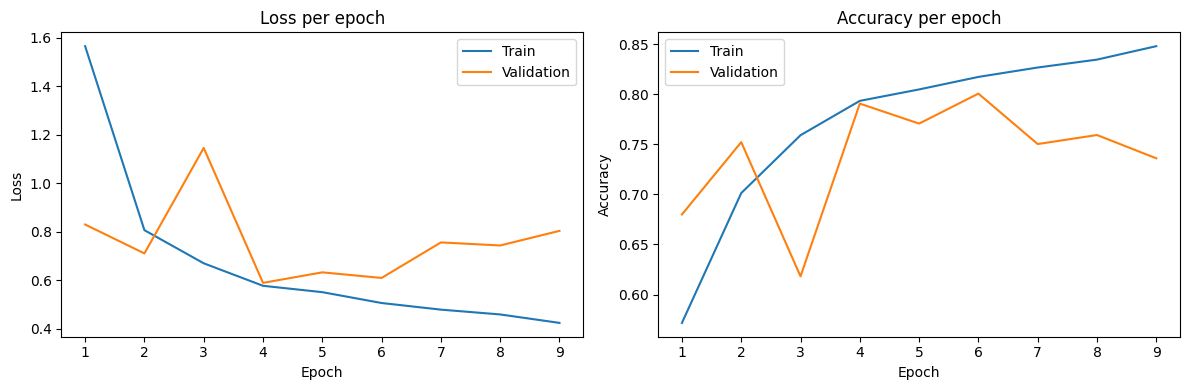

In [9]:
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label="Train")
ax1.plot(epochs_range, val_losses,   label="Validation")
ax1.set_title("Loss per epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_range, train_accs, label="Train")
ax2.plot(epochs_range, val_accs,   label="Validation")
ax2.set_title("Accuracy per epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

# 10. Image Prediction

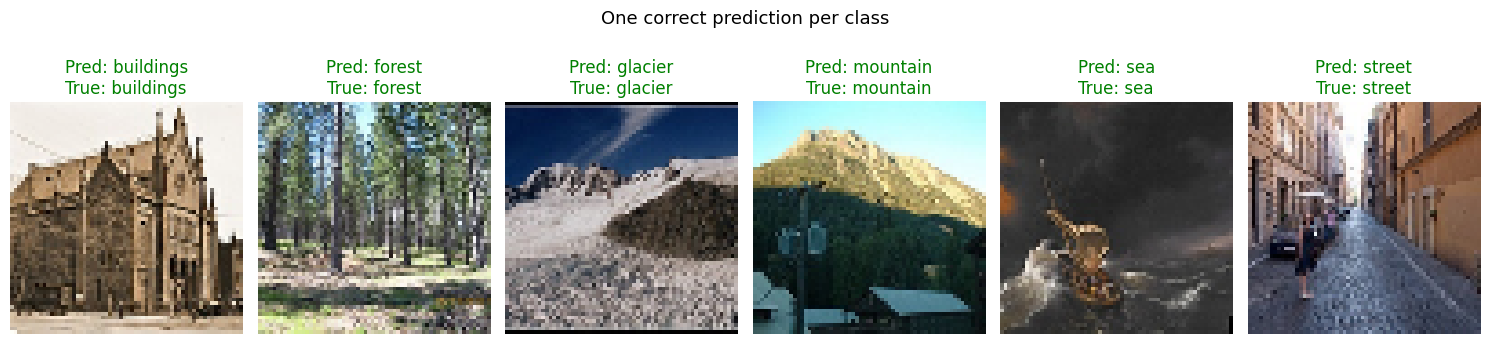

In [10]:
# One correct prediction per class
model.eval()

found = {}

with torch.no_grad():
    # Loop through the entire test loader batch by batch
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds   = outputs.argmax(dim=1).cpu()

        # Check each image in this batch
        for i in range(len(y_batch)):
            true_label = y_batch[i].item()     # .item() converts tensor to plain int
            pred_label = preds[i].item()

            # Only save if: correct prediction AND this class not found yet
            if pred_label == true_label and true_label not in found:
                found[true_label] = (X_batch[i].cpu(), pred_label, true_label)

        # Stop early once we have one image for all 6 classes
        if len(found) == NUM_CLASSES:
            break

# Display the grid
plt.figure(figsize=(15, 4))

for class_idx in range(NUM_CLASSES):
    img_tensor, pred, true = found[class_idx]

    plt.subplot(1, NUM_CLASSES, class_idx + 1)

    # Permute for matplotlib
    img = img_tensor.permute(1, 2, 0).numpy().clip(0, 1)
    plt.imshow(img)

    plt.title(f"Pred: {CLASS_NAMES[pred]}\nTrue: {CLASS_NAMES[true]}", color='green')
    plt.axis('off')

plt.suptitle("One correct prediction per class", fontsize=13)
plt.tight_layout()
plt.show()